In [3]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import glob
import re

In [4]:
iyr=1980;fyr=2025
domain='GRf'
domain_2 = 'GRp'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [5]:
domain_2 = 'GRp'
#domain_3 = 'GRp_bug'

In [6]:
# Fedchenko area
#lon
w=24 ; x=34
#lat
y=40 ; z=52

In [7]:
# Ice thresold, 2025_28_11_Grp*.nc
ice_threshold = 40

In [8]:
# Jasgulem ice core coordinates:
jasg_lat = 38.54063
jasg_lon = 72.269816

In [9]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/MARout_post/' + domain_2 +'/spin2/work/monthly/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [10]:
season_list = ["DJF", "MAM", "JJA", "SON"]

In [11]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [12]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve la carotte Jasgulem

# distance sur grille
dist = np.sqrt((ds_lat - jasg_lat)**2 + (ds_lon - jasg_lon)**2)
# index 1D du minimum
idx_1d = dist.argmin().item()
# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude :", ds_lat[iY, iX].item())
print("Longitude :", ds_lon[iY, iX].item())

Indice Y : 26
Indice X : 47
Latitude : 38.54820251464844
Longitude : 72.30000305175781


### Loading the SEB variables

In [13]:
def load_mar_variable(variable, op, domain, path, k):
    
    fileName = f"{variable}_mon{op}_MARv3.14_ER5_spin2_{domain}_*.nc"
    
    ds = xr.open_mfdataset(path + fileName)[variable].load()
    
    ds = ds.assign_coords(
        X=np.round(ds.X.values),
        Y=np.round(ds.Y.values)
    )
    
    ds = ds.rename({'TIME': 'time'})
    
    return ds[:, k:-k, k:-k]

In [14]:
# Latent Heat Flux (W/m2)
ds_LHF = load_mar_variable('LHF', 'mean', domain_2, sourceData_1, k)

# Sensible Heat Flux (W/m2)
ds_SHF = load_mar_variable('SHF', 'mean', domain_2, sourceData_1, k)

# Long Wave Upward (W/m2)
ds_LWU = load_mar_variable('LWU', 'mean', domain_2, sourceData_1, k)

# Long Wave Downward (W/m2)
ds_LWD = load_mar_variable('LWD', 'mean', domain_2, sourceData_1, k)

# Net long Wave radiation (W/m2)
ds_NLW = ds_LWD - ds_LWU

# Short Wave Downward (W/m2)
ds_SWD = load_mar_variable('SWD', 'mean', domain_2, sourceData_1, k)

# Short Wave Upward (W/m2)
ds_SWU = load_mar_variable('SWU', 'mean', domain_2, sourceData_1, k)

# Net Short Wave radiation (W/m2)
ds_NSW = ds_SWD - ds_SWU

# Ground Flux (W/m2)
ds_GF = load_mar_variable('GF', 'mean', domain_2, sourceData_2, k)

In [34]:
ds_MBMTOP

<xarray.DataArray 'MBMTOP' (time: 312, Y: 62, X: 96)> Size: 7MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
...
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2000-01-16T12:00:00 ... 2025-12-16T12:...
    SECTOR   float32 4B 1.0
  * X        (X) float32 384B -329.0 -322.0 -315.0 -308.0 ... 322.0 329.0 336.0
  * Y        (Y) float32 248B -210.0 -203.0 -196.0 -189.0 ... 203.0 210.0 217.0

In [17]:
# Melt integrated on the entire snow column
    # float ME(TIME, SECTOR1_1, Y, X) ;
    # ME:long_name = "Meltwater production" ;
    # ME:units = "mmWE/day" ;

variable='ME' 

ds = xr.open_mfdataset(sourceData_1 + "ME_monsum_MARv3.14_ER5_spin2_GRp_*.nc").ME.isel(SECTOR1_1=0).load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds = ds[:,k:-k,k:-k]

# Computing energy flux related to melt (W/m2)
Lf = 3.34*10**5 # J.kg**(-1) the latent heat of fusion of water
### APPROX HERE need to calculate the exact value for each month, because month duration vary
t_timestep = 60*60*24*365.5/12 # 60*60*24 seconds in a month
ds_ME = -ds  * Lf / t_timestep

In [18]:
# Refreesing integrated on the entire snow column
    # float RZ(TIME, SECTOR1_1, Y, X) ;
    # RZ:long_name = "Meltwater refreezing and deposition" ;
    # RZ:units = "mmWE/day" ;

variable='RZ' 

ds = xr.open_mfdataset(sourceData_1 + "RZ_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RZ.isel(SECTOR1_1=0).load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds = ds[:,k:-k,k:-k]

# Computing energy flux related to refreezing (W/m2)
Lf = 3.34*10**5 # J.kg**(-1) the latent heat of fusion of water
### APPROX HERE need to calculate the exact value for each month, because month duration vary
t_timestep = 60*60*24*365.5/12 # seconds in a month
ds_RZ = ds * Lf / t_timestep

In [19]:
# MBRTOP:"Refreezing, only top layer"
# VERIFIER QUE SECTOR 0 est bien la BONNE INFO
variable='MBRTOP' 

ds = xr.open_mfdataset(sourceData_2 + "MBRTOP_monsum_MARv3.14_ER5_spin2_GRp_*.nc").MBRTOP.isel(SECTOR=0).load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds = ds[:,k:-k,k:-k]

# Computing energy flux related to refreezing (W/m2)
Lf = 3.34*10**5 # J.kg**(-1) the latent heat of fusion of water
### APPROX HERE need to calculate the exact value for each month, because month duration vary
t_timestep = 60*60*24*365.5/12 # 60*60*24 seconds in a month
ds_MBRTOP = ds  * Lf / t_timestep 

In [20]:
# MBMTOP: "Only Melting, only top layer"
# VERIFIER QUE SECTOR 0 est bien la BONNE INFO
variable='MBMTOP' 

ds = xr.open_mfdataset(sourceData_2 + "MBMTOP_monsum_MARv3.14_ER5_spin2_GRp_*.nc").MBMTOP.isel(SECTOR=0).load()

ds = ds.assign_coords(X=np.round(ds.X.values))
ds = ds.assign_coords(Y=np.round(ds.Y.values))
ds = ds.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds = ds[:,k:-k,k:-k]

# Computing energy flux related to melt (W/m2)
Lf = 3.34*10**5 # J.kg**(-1) the latent heat of fusion of water
### APPROX HERE need to calculate the exact value for each month, because month duration vary
t_timestep = 60*60*24*365.5/12 # 60*60*24 seconds in a month
ds_MBMTOP = -ds  * Lf / t_timestep 

### Evaluating MBRTOP vs RZ

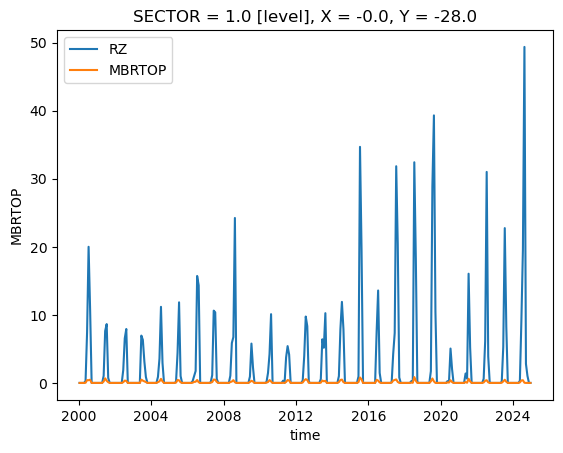

In [21]:
ts2 = ds_RZ.sel(time=slice("2000-01-01", None)).isel(Y=iY, X=iX)
ts1 = ds_MBRTOP.sel(time=slice("2000-01-01", None)).isel(Y=iY, X=iX)

ts1, ts2 = xr.align(ts1, ts2)

fig, ax = plt.subplots()
ts2.plot(ax=ax, label='RZ')
ts1.plot(ax=ax, label='MBRTOP')

ax.legend()
plt.show()

### Evaluating MBMTOP vs ME

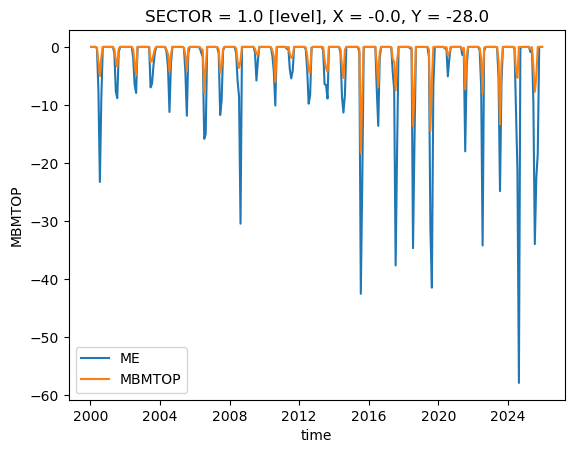

In [22]:
ts1 = ds_MBMTOP.sel(time=slice("2000-01-01", None)).isel(Y=iY, X=iX)
ts2 = ds_ME.sel(time=slice("2000-01-01", None)).isel(Y=iY, X=iX)

ts1, ts2 = xr.align(ts1, ts2)

fig, ax = plt.subplots()
ts2.plot(ax=ax, label='ME')
ts1.plot(ax=ax, label='MBMTOP')

ax.legend()
plt.show()

## Composantes du SEB 

In [23]:
seb_dataset = {
    "SHF": ds_SHF,
    "LHF": ds_LHF,
    "NLW": ds_NLW,
    "NSW": ds_NSW,
    "Melt" : ds_MBMTOP,
    "Refreeze" : ds_MBRTOP,
    "GF":  ds_GF
}

### Composantes du SEB au point de grille du forage 2025 Jasgulem Pass

In [25]:
seb_dataset = {
    "SHF": ds_SHF,
    "LHF": ds_LHF,
    "NLW": ds_NLW,
    "NSW": ds_NSW,
    "Melt" : ds_ME,
    "Refreeze" : ds_RZ,
    "GF":  ds_GF
}

# Période cible
start_date = "2014-09-01"
end_date = "2025-08-31"

# Filtrer les données temporellement
seb_filtered = {}
for key, da in seb_dataset.items():
    seb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
seb_jasg = {}
for key, da in seb_filtered.items():
    seb_jasg[key] = da.isel(Y=iY, X=iX)


# Composantes du SEB
components = ["SHF", "LHF", "NSW", "NLW", "Melt", "Refreeze", "GF"]
labels = {
    "SHF": "Sensible Heat Flux",
    "LHF": "Latent Heat Flux",
    "NSW": "Net Shortwave",
    "NLW": "Net Longwave",
    "Melt": "Snowmelt Energy (variable ME)",
    "Refreeze": "Refreezing Energy (variable RZ)",
    "GF": "Ground Flux"
}

# Couleurs pour les histos
colors = {
    "SHF": "#e41a1c",  
    "LHF": "#377eb8",  
    "NSW": "#ff7f00", 
    "NLW": "#984ea3", 
    "Melt":  "#4daf4a", 
    "Refreeze": "#00BFC4",
    "GF":  "#a65628"   
}

# Temps et données
time = seb_jasg[components[0]].time.values
data = np.array([seb_jasg[comp].values for comp in components])

fig, ax = plt.subplots(figsize=(16, 7))

# Initialisation cumul
cumulative_pos = np.zeros_like(data[0])
cumulative_neg = np.zeros_like(data[0])

time_num = mdates.date2num(time)
width = np.median(np.diff(time_num)) * 0.8

for i, comp in enumerate(components):
    values = data[i]

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(
        time,
        pos,
        width=width,
        bottom=cumulative_pos,
        color=colors[comp],
        label=labels[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    ax.bar(
        time,
        neg,
        width=width,
        bottom=cumulative_neg,
        color=colors[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    cumulative_pos += pos
    cumulative_neg += neg

# Ligne zéro
ax.axhline(0, color='black', linewidth=1)

# Labels
ax.set_ylabel("Energy flux (W m$^{-2}$)")
ax.set_xlabel("Time")

# Format date
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
fig.suptitle(f"Seasonnal surface energy balance – location: 2025 drilling Jasgulem gridd cell ", fontsize=14)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("SEB_Jasgulem_2014-2025_ME_RZ.png", dpi=300, bbox_inches="tight")

plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (7,) + inhomogeneous part.

### On ne peut pas utiliser ME et RZn on garde le plot ci dessous

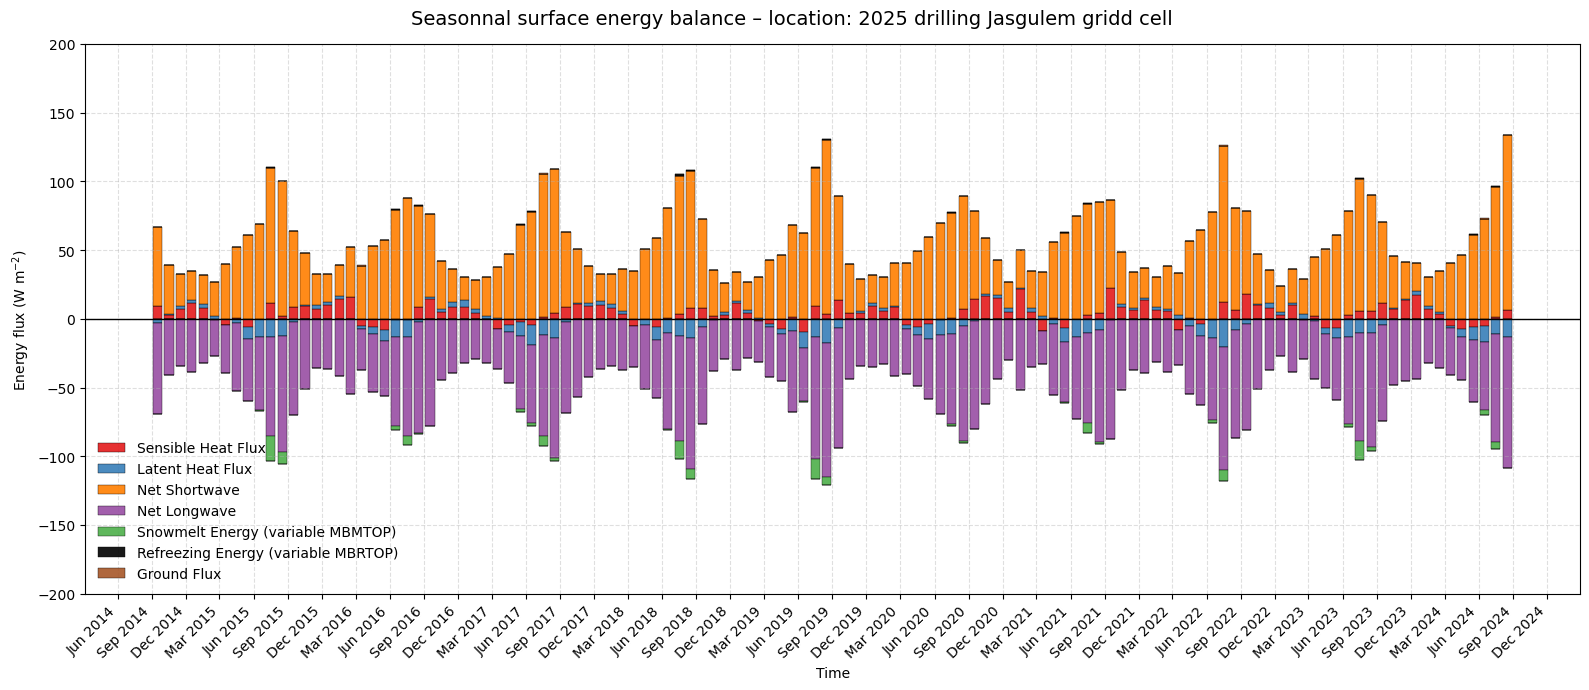

In [22]:
seb_dataset = {
    "SHF": ds_SHF,
    "LHF": ds_LHF,
    "NLW": ds_NLW,
    "NSW": ds_NSW,
    "Melt" : ds_MBMTOP,
    "Refreeze" : ds_MBRTOP,
    "GF":  ds_GF
}

# Période cible
start_date = "2014-09-01"
end_date = "2024-08-31"

# Filtrer les données temporellement
seb_filtered = {}
for key, da in seb_dataset.items():
    seb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
seb_jasg = {}
for key, da in seb_filtered.items():
    seb_jasg[key] = da.isel(Y=iY, X=iX)


# Composantes du SEB
components = ["SHF", "LHF", "NSW", "NLW", "Melt", "Refreeze", "GF"]
labels = {
    "SHF": "Sensible Heat Flux",
    "LHF": "Latent Heat Flux",
    "NSW": "Net Shortwave",
    "NLW": "Net Longwave",
    "Melt": "Snowmelt Energy (variable MBMTOP)",
    "Refreeze": "Refreezing Energy (variable MBRTOP)",
    "GF": "Ground Flux"
}

# Couleurs pour les histos
colors = {
    "SHF": "#e41a1c",  
    "LHF": "#377eb8",  
    "NSW": "#ff7f00", 
    "NLW": "#984ea3", 
    "Melt":  "#4daf4a", 
    "Refreeze": "black",
    "GF":  "#a65628"   
}

# Temps et données
time = seb_jasg[components[0]].time.values
data = np.array([seb_jasg[comp].values for comp in components])

fig, ax = plt.subplots(figsize=(16, 7))

# Initialisation cumul
cumulative_pos = np.zeros_like(data[0])
cumulative_neg = np.zeros_like(data[0])

time_num = mdates.date2num(time)
width = np.median(np.diff(time_num)) * 0.8

for i, comp in enumerate(components):
    values = data[i]

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(
        time,
        pos,
        width=width,
        bottom=cumulative_pos,
        color=colors[comp],
        label=labels[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    ax.bar(
        time,
        neg,
        width=width,
        bottom=cumulative_neg,
        color=colors[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    cumulative_pos += pos
    cumulative_neg += neg

# Ligne zéro
ax.axhline(0, color='black', linewidth=1)

# Labels
ax.set_ylabel("Energy flux (W m$^{-2}$)")
ax.set_xlabel("Time")

# Format date
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
fig.suptitle(f"Seasonnal surface energy balance – location: 2025 drilling Jasgulem gridd cell ", fontsize=14)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
ax.set_ylim(-200, 200)

plt.savefig("SEB_Jasgulem_2014-2024_MBMTOP_MBRTOP.png", dpi=300, bbox_inches="tight")

plt.show()

/tmp/ipykernel_1663744/327003123.py:64: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


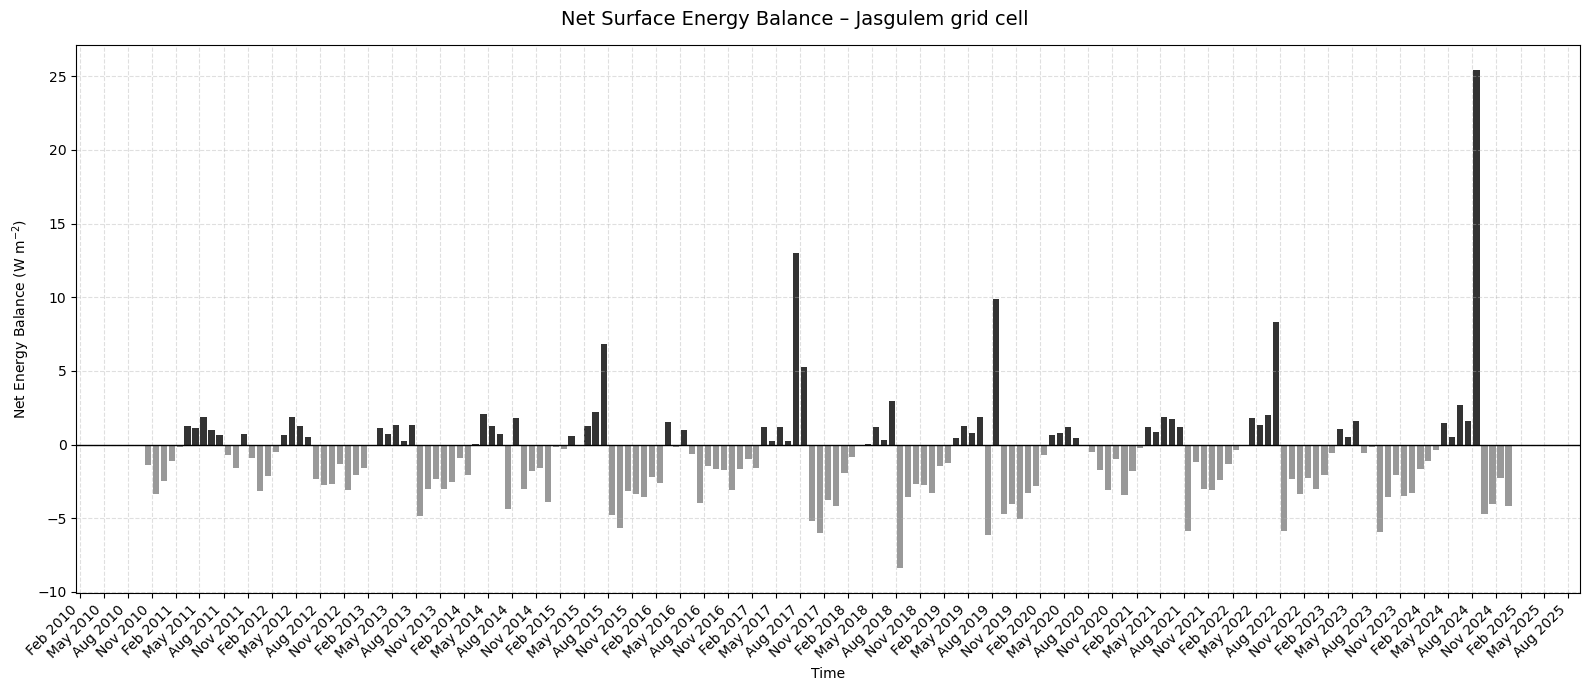

In [25]:
# Période cible
start_date = "2010-10-01"
end_date = "2025-09-30"

# Filtrer les données temporellement
seb_filtered = {}
for key, da in seb_dataset.items():
    seb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
seb_jasg = {}
for key, da in seb_filtered.items():
    seb_jasg[key] = da.isel(Y=iY, X=iX)

# Calcul de la résultante du SEB
seb_net = (
    seb_jasg["SHF"]
    + seb_jasg["LHF"]
    + seb_jasg["NSW"]
    + seb_jasg["NLW"]
    + seb_jasg["Melt"]
    + seb_jasg["Refreeze"]  
    + seb_jasg["GF"]
)


# Temps et données
time = seb_net.time.values
values = seb_net.values

fig, ax = plt.subplots(figsize=(16, 7))

pos = np.where(values > 0, values, 0)
neg = np.where(values < 0, values, 0)

time_num = mdates.date2num(time)
width = np.median(np.diff(time_num)) * 0.8

ax.bar(
    time,
    pos,
    width=width,
    color="black",
    alpha=0.8,
)

ax.bar(
    time,
    neg,
    width=width,
    color="gray",
    alpha=0.8,
)

ax.axhline(0, color="black", linewidth=1)

ax.set_ylabel("Net Energy Balance (W m$^{-2}$)")
ax.set_xlabel("Time")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Net Surface Energy Balance – Jasgulem grid cell", fontsize=14)

plt.tight_layout()
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'AS-SEP' is deprecated and will be removed in a future version, please use 'YS-SEP' instead.
  self.index_grouper = pd.Grouper(
/tmp/ipykernel_1663744/766852439.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


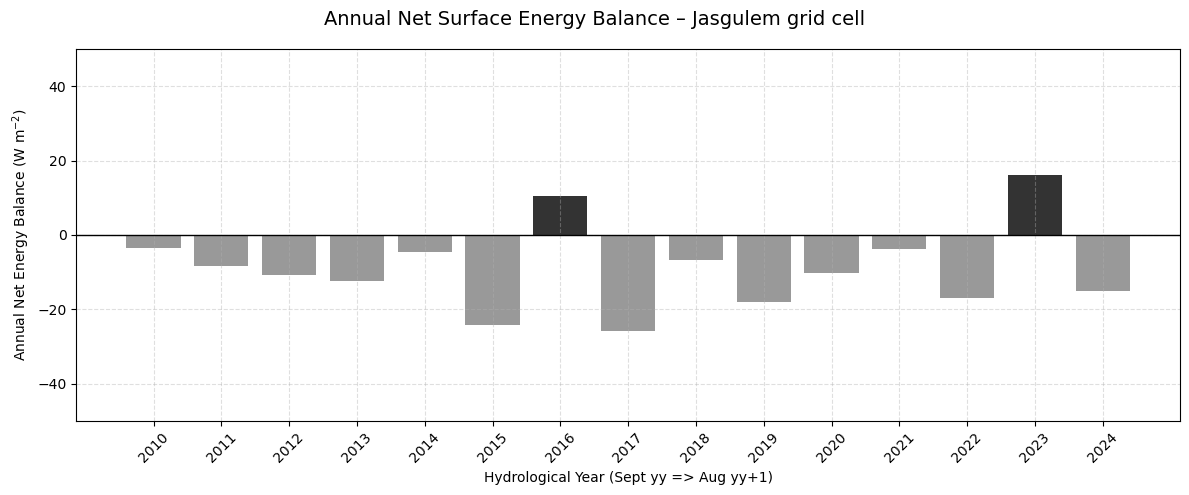

In [26]:
# Période cible
start_date = "2010-10-01"
end_date = "2025-09-30"

# Filtrage temporel
seb_filtered = {
    key: da.sel(time=slice(start_date, end_date))
    for key, da in seb_dataset.items()
}

# extraction pixel
seb_jasg = {
    key: da.isel(Y=iY, X=iX)
    for key, da in seb_filtered.items()
}

# SEB net
seb_net = (
    seb_jasg["SHF"]
    + seb_jasg["LHF"]
    + seb_jasg["NSW"]
    + seb_jasg["NLW"]
    + seb_jasg["Melt"]
    + seb_jasg["Refreeze"]
    + seb_jasg["GF"]
)

# =========================
# AGRÉGATION ANNUELLE (HYDRO YEAR SEP→AUG)
# =========================

seb_yearly = seb_net.resample(time="AS-SEP").sum()

# conversion propre des axes
years = seb_yearly["time.year"].values
values = seb_yearly.values

# =========================
# PLOT
# =========================

fig, ax = plt.subplots(figsize=(12, 5))

pos = np.where(values > 0, values, 0)
neg = np.where(values < 0, values, 0)

ax.bar(years, pos, color="black", alpha=0.8)
ax.bar(years, neg, color="gray", alpha=0.8)

ax.axhline(0, color="black", linewidth=1)

ax.set_ylabel("Annual Net Energy Balance (W m$^{-2}$)")
ax.set_xlabel("Hydrological Year (Sept yy => Aug yy+1)")

ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Annual Net Surface Energy Balance – Jasgulem grid cell", fontsize=14)
ax.set_ylim(-50, 50)

plt.savefig("FIG_seb.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

Indice Y : 26
Indice X : 47


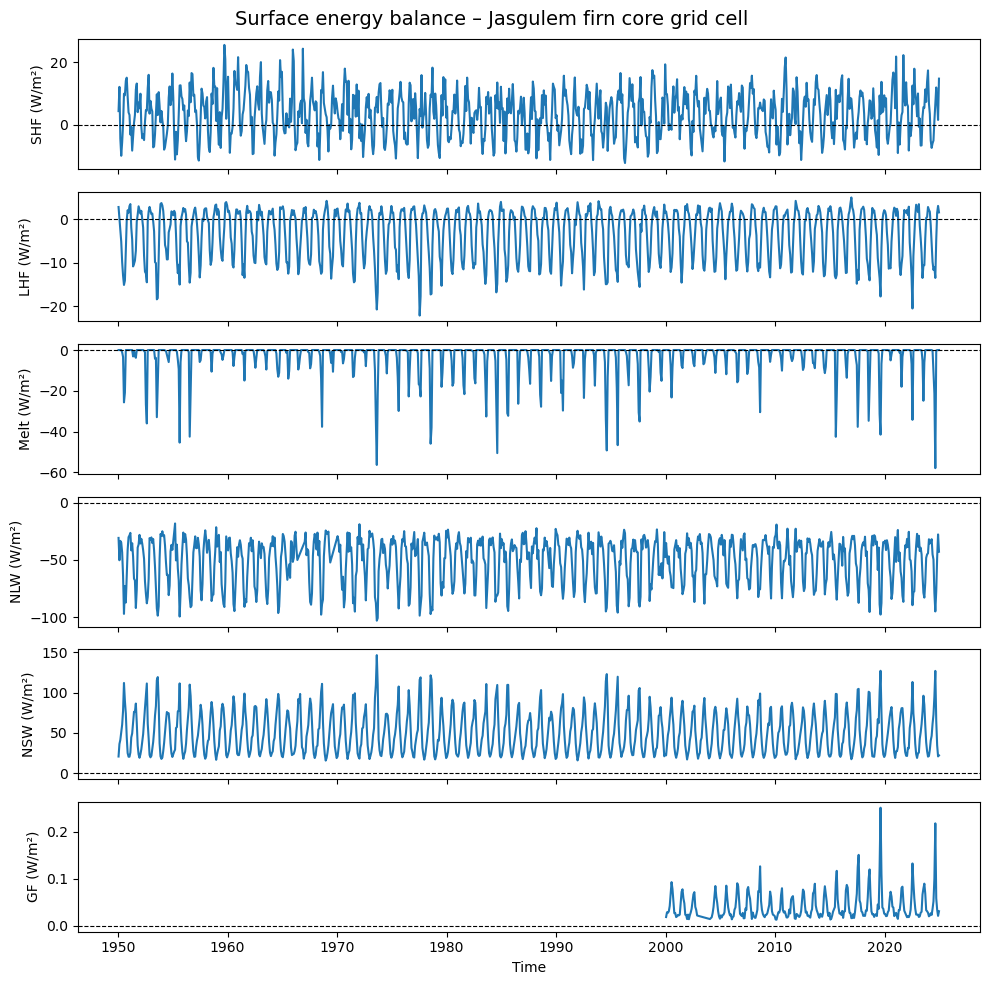

In [26]:
print("Indice Y :", iY)
print("Indice X :", iX)

fig, axes = plt.subplots(
    nrows=6,
    ncols=1,
    figsize=(10, 10),
    sharex=True
)

datasets = [
    ds_SHF, ds_LHF, ds_ME, ds_NLW,
    ds_NSW, ds_GF
]

ylabels = [
    "SHF (W/m²)", "LHF (W/m²)", "Melt (W/m²)",
    "NLW (W/m²)",
    "NSW (W/m²)",
    "GF (W/m²)"
]

# plots
for i, (ax, ds, yl) in enumerate(zip(axes, datasets, ylabels)):
    ds.isel(Y=iY, X=iX).plot(
        ax=ax,
    )
    ax.set_ylabel(yl)
    ax.set_title("")
    ax.set_xlabel("")
    ax.axhline(0, color="k", linewidth=0.8, linestyle="--")

axes[-1].set_xlabel("Time")

# Titre global
fig.suptitle(
    f"Surface energy balance – Jasgulem firn core grid cell ",
    fontsize=14
)

plt.subplots_adjust(top=0.93)
plt.tight_layout()
plt.show()

Indice Y : 26
Indice X : 47


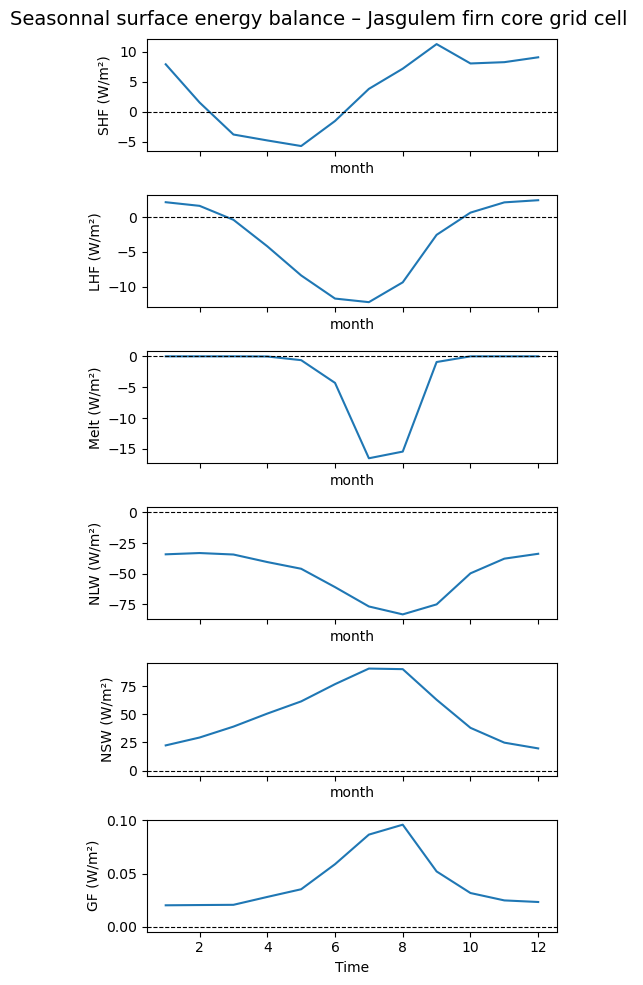

In [19]:
print("Indice Y :", iY)
print("Indice X :", iX)

fig, axes = plt.subplots(
    nrows=6,
    ncols=1,
    figsize=(5, 10),
    sharex=True
)

datasets = [
    ds_SHF.groupby('time.month').mean('time', skipna=True), 
    ds_LHF.groupby('time.month').mean('time', skipna=True), 
    ds_ME.groupby('time.month').mean('time', skipna=True), 
    ds_NLW.groupby('time.month').mean('time', skipna=True),
    ds_NSW.groupby('time.month').mean('time', skipna=True),
    ds_GF.groupby('time.month').mean('time', skipna=True)
]

ylabels = [
    "SHF (W/m²)", "LHF (W/m²)", "Melt (W/m²)",
    "NLW (W/m²)",
    "NSW (W/m²)",
    "GF (W/m²)"
]

# plots
for i, (ax, ds, yl) in enumerate(zip(axes, datasets, ylabels)):
    ds.isel(Y=iY, X=iX).plot(
        ax=ax,
    )

    ax.set_ylabel(yl)
    ax.set_title("")
    ax.axhline(0, color="k", linewidth=0.8, linestyle="--")

axes[-1].set_xlabel("Time")

fig.suptitle(
    f"Seasonnal surface energy balance – Jasgulem firn core grid cell ",
    fontsize=14
)

plt.subplots_adjust(top=0.93)
plt.tight_layout()
plt.show()


## Composantes du SEB sur les 2x2 mailles Nord-Ouest du forage 2025

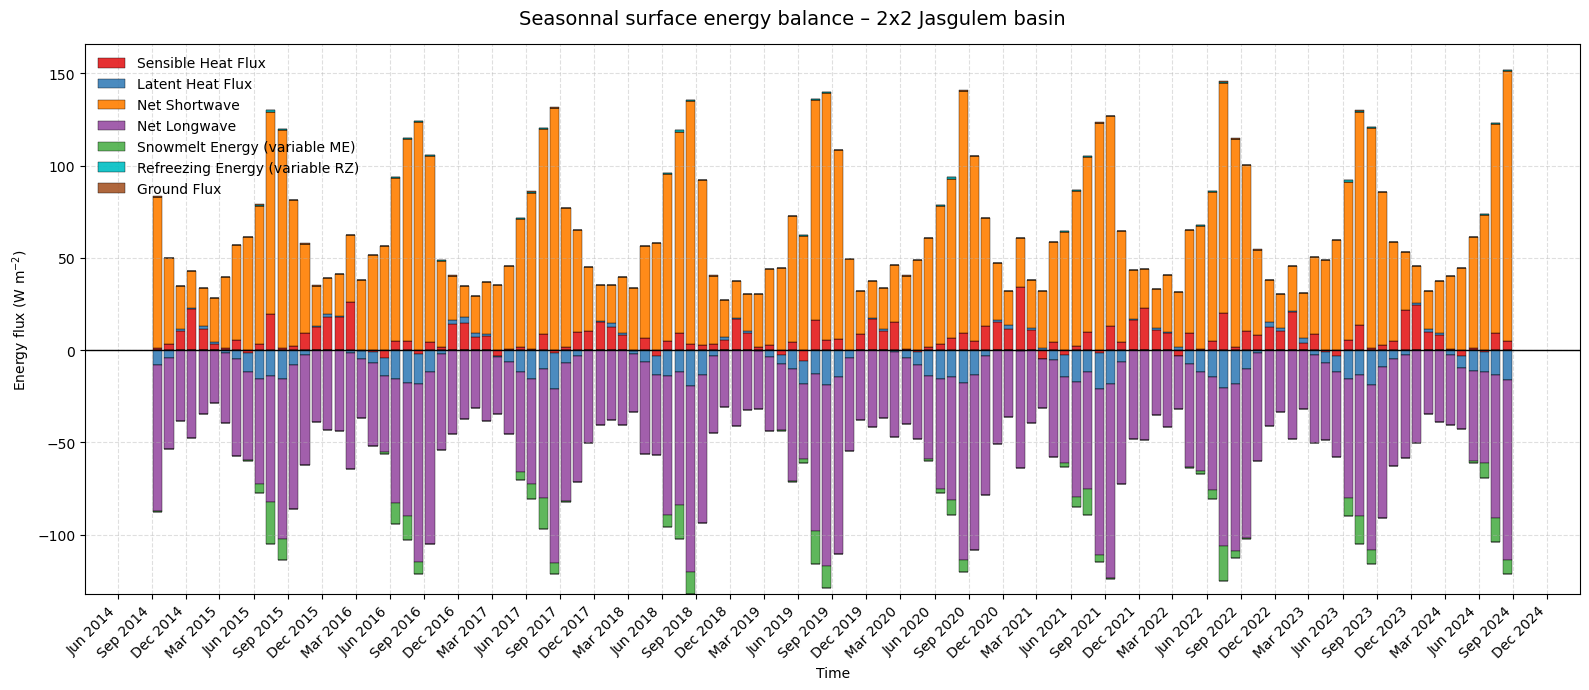

In [28]:
# Période cible
start_date = "2014-09-01"
end_date = "2024-08-31"

# Filtrer les données temporellement
seb_filtered = {}
for key, da in seb_dataset.items():
    seb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
seb_jasg = {}
for key, da in seb_filtered.items():
    seb_jasg[key] = da.isel(Y=slice(iY, iY+2), X=slice(iX-1, iX+1)).mean(dim=("Y", "X"))

# Composantes du SEB
components = ["SHF", "LHF", "NSW", "NLW", "Melt", "Refreeze", "GF"]
labels = {
    "SHF": "Sensible Heat Flux",
    "LHF": "Latent Heat Flux",
    "NSW": "Net Shortwave",
    "NLW": "Net Longwave",
    "Melt": "Snowmelt Energy (variable ME)",
    "Refreeze": "Refreezing Energy (variable RZ)",
    "GF": "Ground Flux"
}

# Couleurs pour les histos
colors = {
    "SHF": "#e41a1c",  
    "LHF": "#377eb8",  
    "NSW": "#ff7f00", 
    "NLW": "#984ea3", 
    "Melt":  "#4daf4a", 
    "Refreeze": "#00BFC4",
    "GF":  "#a65628"   
}

# Temps et données
time = seb_jasg[components[0]].time.values
data = np.array([seb_jasg[comp].values for comp in components])

fig, ax = plt.subplots(figsize=(16, 7))

# Initialisation cumul
cumulative_pos = np.zeros_like(data[0])
cumulative_neg = np.zeros_like(data[0])

time_num = mdates.date2num(time)
width = np.median(np.diff(time_num)) * 0.8

for i, comp in enumerate(components):
    values = data[i]

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(
        time,
        pos,
        width=width,
        bottom=cumulative_pos,
        color=colors[comp],
        label=labels[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    ax.bar(
        time,
        neg,
        width=width,
        bottom=cumulative_neg,
        color=colors[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    cumulative_pos += pos
    cumulative_neg += neg

# Ligne zéro
ax.axhline(0, color='black', linewidth=1)

# Labels
ax.set_ylabel("Energy flux (W m$^{-2}$)")
ax.set_xlabel("Time")

# Format date
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
fig.suptitle(f"Seasonnal surface energy balance – 2x2 Jasgulem basin ", fontsize=14)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Composante du SEB en zone d'ablation de Fedchenko

In [57]:
print("Indice Y Jasgulem firn drilling :", iY)
print("Indice X Jasgulem firn drilling :", iX)
print("Latitude Jasgulem firn drilling :", ds_lat[iY, iX].item())
print("Longitude Jasgulem firn drilling:", ds_lon[iY, iX].item())
#print(jasg_lon, jasg_lat)

abl_lat = ds_lat[iY+4, iX].item()
abl_lon = ds_lon[iY+4, iX].item()
abl_alt = ds_SH[iY+4, iX].item()
print("Latitude Fedchenko ablation area :", abl_lat)
print("Longitude Fedchenko ablation area:", abl_lon)
print("Altitude Fedchenko ablation area:", abl_alt)

Indice Y Jasgulem firn drilling : 26
Indice X Jasgulem firn drilling : 47
Latitude Jasgulem firn drilling : 38.54820251464844
Longitude Jasgulem firn drilling: 72.30000305175781
Latitude Fedchenko ablation area : 38.799991607666016
Longitude Fedchenko ablation area: 72.30000305175781
Altitude Fedchenko ablation area: 4667.09326171875


/tmp/ipykernel_1515573/1156356086.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


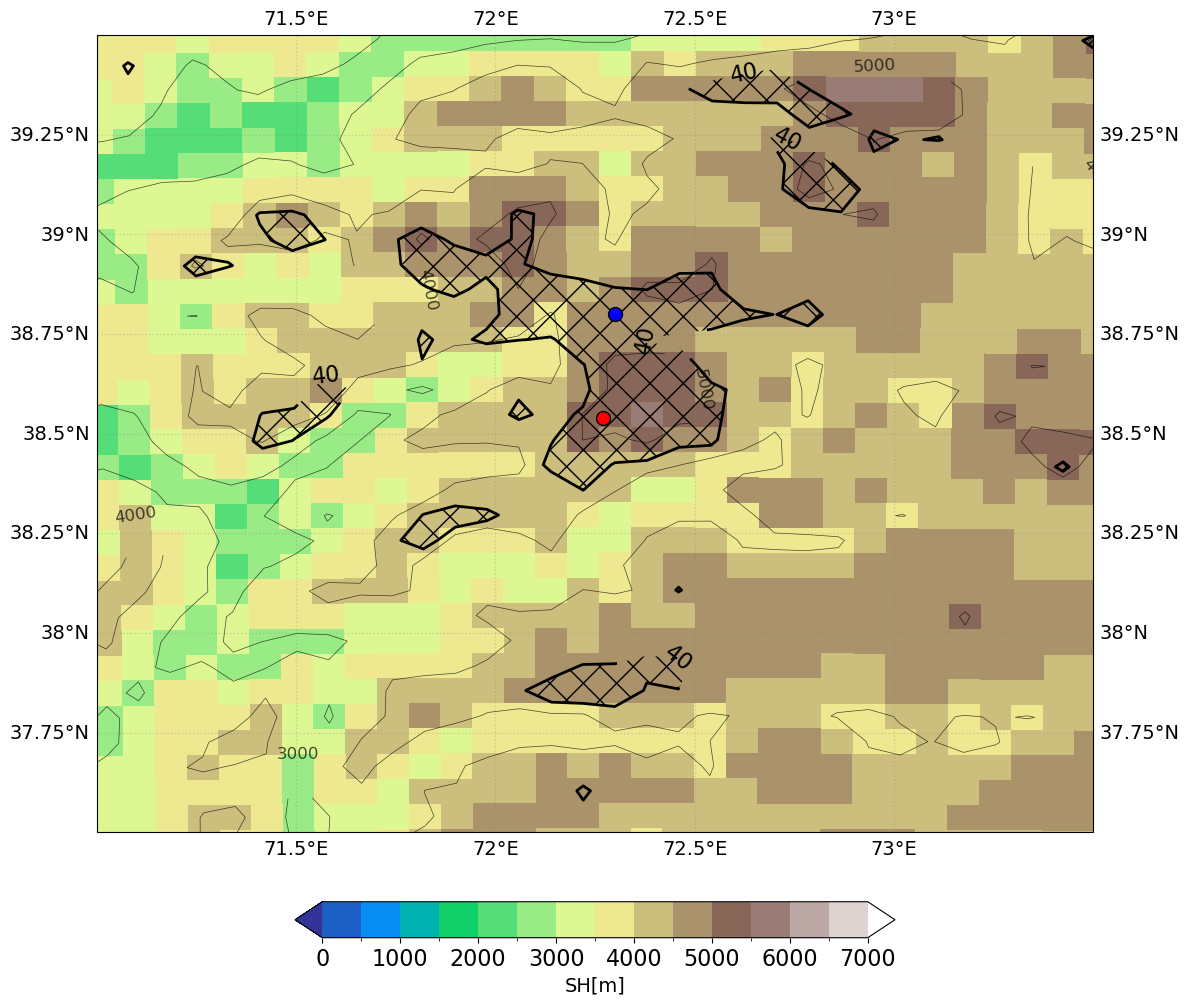

In [66]:
# grill cell considered
ice_level=40# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
ax.set_extent([71, 73.5, 37.5, 39.5], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Jasgulem ice core : red dot
ax.plot(jasg_lon, jasg_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#Ablation grid cell considered
ax.plot(abl_lon, abl_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='blue',
        transform=ccrs.PlateCarree())

plt.savefig("fig", dpi=300, bbox_inches="tight")

plt.show()

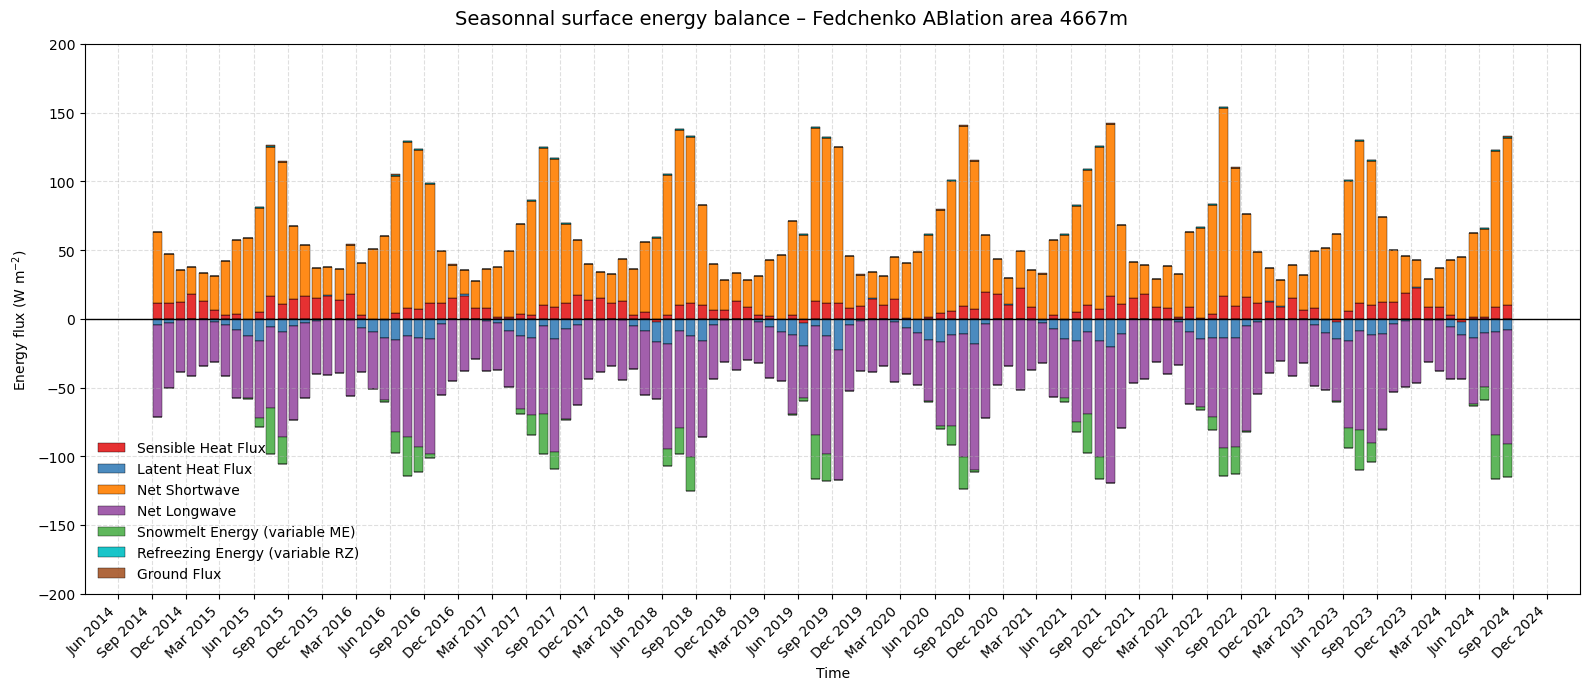

In [68]:
seb_dataset = {
    "SHF": ds_SHF,
    "LHF": ds_LHF,
    "NLW": ds_NLW,
    "NSW": ds_NSW,
    "Melt" : ds_MBMTOP,
    "Refreeze" : ds_MBRTOP,
    "GF":  ds_GF
}

# Période cible
start_date = "2014-09-01"
end_date = "2024-08-31"

# Filtrer les données temporellement
seb_filtered = {}
for key, da in seb_dataset.items():
    seb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
seb_jasg = {}
for key, da in seb_filtered.items():
    seb_jasg[key] = da.isel(Y=iY+4, X=iX)

# Composantes du SEB
components = ["SHF", "LHF", "NSW", "NLW", "Melt", "Refreeze", "GF"]
labels = {
    "SHF": "Sensible Heat Flux",
    "LHF": "Latent Heat Flux",
    "NSW": "Net Shortwave",
    "NLW": "Net Longwave",
    "Melt": "Snowmelt Energy (variable ME)",
    "Refreeze": "Refreezing Energy (variable RZ)",
    "GF": "Ground Flux"
}

# Couleurs pour les histos
colors = {
    "SHF": "#e41a1c",  
    "LHF": "#377eb8",  
    "NSW": "#ff7f00", 
    "NLW": "#984ea3", 
    "Melt":  "#4daf4a", 
    "Refreeze": "#00BFC4",
    "GF":  "#a65628"   
}

# Temps et données
time = seb_jasg[components[0]].time.values
data = np.array([seb_jasg[comp].values for comp in components])

fig, ax = plt.subplots(figsize=(16, 7))

# Initialisation cumul
cumulative_pos = np.zeros_like(data[0])
cumulative_neg = np.zeros_like(data[0])

time_num = mdates.date2num(time)
width = np.median(np.diff(time_num)) * 0.8

for i, comp in enumerate(components):
    values = data[i]

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(
        time,
        pos,
        width=width,
        bottom=cumulative_pos,
        color=colors[comp],
        label=labels[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    ax.bar(
        time,
        neg,
        width=width,
        bottom=cumulative_neg,
        color=colors[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    cumulative_pos += pos
    cumulative_neg += neg

# Ligne zéro
ax.axhline(0, color='black', linewidth=1)

# Labels
ax.set_ylabel("Energy flux (W m$^{-2}$)")
ax.set_xlabel("Time")

# Format date
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
fig.suptitle(f"Seasonnal surface energy balance – Fedchenko Ablation area 4667m", fontsize=14)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
ax.set_ylim(-200, 200)

plt.savefig("FIG_seb.png", dpi=300, bbox_inches="tight")

plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'AS-SEP' is deprecated and will be removed in a future version, please use 'YS-SEP' instead.
  self.index_grouper = pd.Grouper(
/tmp/ipykernel_1515573/1802608254.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


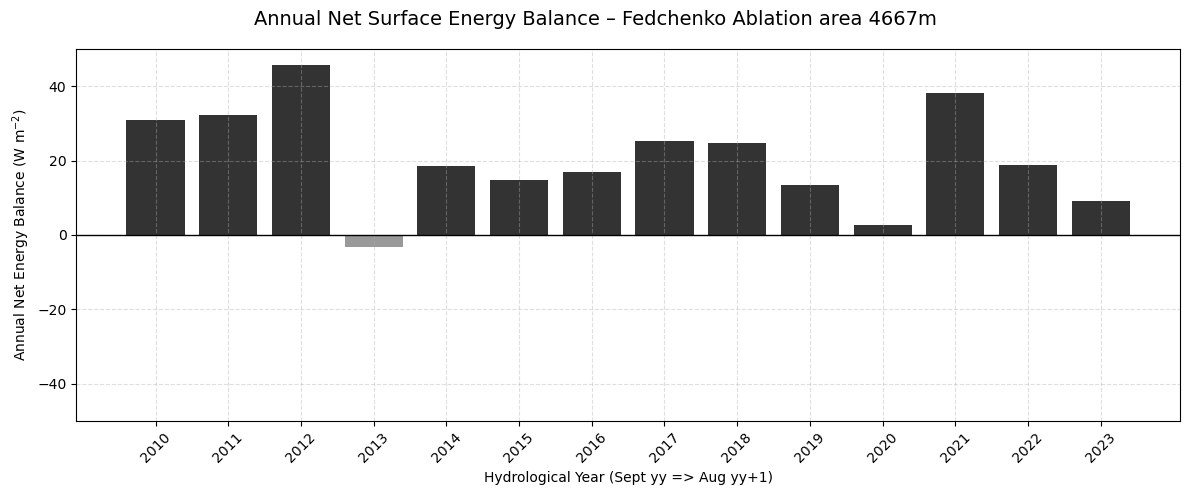

In [74]:
# Période cible
start_date = "2010-09-01"
end_date = "2024-08-31"

# Filtrage temporel
seb_filtered = {
    key: da.sel(time=slice(start_date, end_date))
    for key, da in seb_dataset.items()
}

# extraction pixel
seb_jasg = {
    key: da.isel(Y=iY+4, X=iX)
    for key, da in seb_filtered.items()
}

# SEB net
seb_net = (
    seb_jasg["SHF"]
    + seb_jasg["LHF"]
    + seb_jasg["NSW"]
    + seb_jasg["NLW"]
    + seb_jasg["Melt"]
    + seb_jasg["Refreeze"]
    + seb_jasg["GF"]
)

# =========================
# AGRÉGATION ANNUELLE (HYDRO YEAR SEP→AUG)
# =========================

seb_yearly = seb_net.resample(time="AS-SEP").sum()

# conversion propre des axes
years = seb_yearly["time.year"].values
values = seb_yearly.values

# =========================
# PLOT
# =========================

fig, ax = plt.subplots(figsize=(12, 5))

pos = np.where(values > 0, values, 0)
neg = np.where(values < 0, values, 0)

ax.bar(years, pos, color="black", alpha=0.8)
ax.bar(years, neg, color="gray", alpha=0.8)

ax.axhline(0, color="black", linewidth=1)

ax.set_ylabel("Annual Net Energy Balance (W m$^{-2}$)")
ax.set_xlabel("Hydrological Year (Sept yy => Aug yy+1)")

ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)

fig.suptitle("Annual Net Surface Energy Balance – Fedchenko Ablation area 4667m", fontsize=14)
ax.set_ylim(-50, 50)

plt.savefig("FIG_seb.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

### Composantes du SEB pour l'ensemble du glacier Fedchenko ?
pas de sens physique, pas possible de représenter le glacier (rocheux)

In [75]:
ds_ICE_expanded = ds_ICE.expand_dims({"time": ds_LHF.time}).transpose("time", "Y", "X")

In [76]:
ds_ICE_Fed = ds_ICE[w:x,y:z]
ds_lon_Fed = ds_lon[w:x,y:z]
ds_lat_Fed = ds_lat[w:x,y:z]
ds_SH_Fed = ds_SH[w:x,y:z]

In [77]:
print('min atitude of selected Fechenko glacier area: ', ds_SH_Fed.min())
print('max atitude of selected Fechenko glacier area: ', ds_SH_Fed.max())
print('mean atitude of selected Fechenko glacier area: ', ds_SH_Fed.mean(skipna=True))
count = np.count_nonzero(~np.isnan(ds_SH_Fed))
count_all = ds_SH_Fed.size
print('mean atitude of selected Fechenko glacier area: ',count)
print('mean atitude of selected Fechenko glacier area: ',count_all)

min atitude of selected Fechenko glacier area:  <xarray.DataArray 'SH' ()> Size: 4B
array(2857.7615, dtype=float32)
max atitude of selected Fechenko glacier area:  <xarray.DataArray 'SH' ()> Size: 4B
array(5668.944, dtype=float32)
mean atitude of selected Fechenko glacier area:  <xarray.DataArray 'SH' ()> Size: 4B
array(4452.6855, dtype=float32)
mean atitude of selected Fechenko glacier area:  120
mean atitude of selected Fechenko glacier area:  120


In [ ]:
ds_Fed = xr.Dataset({
    name: xr.where(ds_ICE_expanded > ice_threshold, ds, np.nan)
    for name, ds in seb_dataset.items()
}).isel(X=slice(w, x), Y=slice(y, z))
#dsF['ME']